In [1]:
USING_KAGGLE = True
import os
import math
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
#os.environ['TUNE_DISABLE_STRICT_METRIC_CHECKING'] = '1'

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [2]:
!mkdir best_run_plots tuned_run_plots default_run_plots varying_rs_run_plots models models/tuning models/default models/tuned models/varying_random_state
%pip install pyngrok mlflow lion_pytorch torch-optimizer optax onnx onnxscript ray[tune]==2.44.1 adabelief-pytorch==0.2.0 -q
%pip install --upgrade seaborn -q
%pip install protobuf==3.20.0 -q
!git clone https://github.com/nanowell/AdEMAMix-Optimizer-Pytorch
!mv AdEMAMix-Optimizer-Pytorch AdEMAMix_Optimizer_Pytorch
!git clone https://github.com/xinyuluo8561/Stacey
!cp Stacey/Stacey/staceybase.py .
%pip install schedulefree galore-torch git+https://github.com/KellerJordan/Muon -q
from AdEMAMix_Optimizer_Pytorch.AdEMAMix import AdEMAMix
from schedulefree import AdamWScheduleFree

from galore_torch import GaLoreAdamW as GaLoreAdamW_
from Stacey.Stacey.staceyp2 import Stacey_p2
# param_groups = [{'params': non_galore_params}, 
#                 {'params': galore_params, 'rank': 128, 'update_proj_gap': 200, 'scale': 0.25, 'proj_type': 'std'}]
# optimizer = GaLoreAdamW(param_groups, lr=0.01)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 MB 26.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 68.4 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 65.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 693.4/693.4 kB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.1/133.1 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import time
import inspect
from typing import Tuple

import numpy as np
import pandas as pd
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from torchmetrics import MetricCollection
from torchmetrics.classification import MulticlassROC
from torchmetrics.classification import MulticlassAccuracy, MulticlassF1Score, MulticlassPrecision, MulticlassRecall
from torchvision import transforms
from torchvision.transforms import v2, ToTensor
from torchinfo import summary

import pytorch_lightning as pl
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from pytorch_lightning import seed_everything

import mlflow
import mlflow.pytorch
from mlflow.tracking import MlflowClient

import random

import seaborn as sns

import ray
from ray.train.torch import enable_reproducibility
from ray import tune
from ray.tune.integration.pytorch_lightning import TuneReportCallback
from ray.air.integrations.mlflow import MLflowLoggerCallback, setup_mlflow
from ray.tune import JupyterNotebookReporter
from ray.tune.schedulers import ASHAScheduler
from ray.air import session

from pprint import pprint

from torch.optim import AdamW
from torch_optimizer import Adahessian as AdaHessian
from adabelief_pytorch import AdaBelief
from lion_pytorch import Lion

import matplotlib.pyplot as plt

In [4]:
from torch.optim import Optimizer

class GaLoreAdamW(GaLoreAdamW_):
    pass

In [5]:
def preprocess_data(filename: str) -> torch.Tensor:
    """Function to preprocess data

    Args:
        filename (str): Filename of data to be preprocessed.

    Returns:
        torch.Tensor: preprocessed data
    """
    data = pd.read_csv(filename)

    data_t = torch.Tensor(data.values)
    data_t = torch.nn.functional.normalize(data_t)

    return data_t


def get_train_valid_test_datasets(
    train_filename: str, test_filename: str
) -> Tuple[TensorDataset, ...]:
    train_df = pd.read_csv(train_filename)
    test_df = pd.read_csv(test_filename)

    X_train, X_valid, y_train, y_valid = train_test_split(
        train_df.iloc[:, :-1].values, train_df.iloc[:, -1].values, random_state=0
    )

    X_train_np = X_train.astype(np.float32)
    y_train_np = y_train.astype(np.int64)
    X_valid_np = X_valid.astype(np.float32)
    y_valid_np = y_valid.astype(np.int64)

    X_test_np = test_df.iloc[:, :-1].values.astype(np.float32)
    y_test_np = test_df.iloc[:, -1].values.astype(np.int64)

    scaler = StandardScaler()
    X_train_scaled_np = scaler.fit_transform(X_train_np)
    X_valid_scaled_np = scaler.fit_transform(X_valid_np)
    X_test_scaled_np = scaler.transform(X_test_np)

    X_train_tensor = torch.tensor(X_train_scaled_np, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_np, dtype=torch.int64)
    X_valid_tensor = torch.tensor(X_valid_scaled_np, dtype=torch.float32)
    y_valid_tensor = torch.tensor(y_valid_np, dtype=torch.int64)
    X_test_tensor = torch.tensor(X_test_scaled_np, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test_np, dtype=torch.int64)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    return train_dataset, valid_dataset, test_dataset


In [6]:
SEED = 0
NUM_THREADS = 4
TORCH_GENERATOR: torch.Generator = torch.Generator()
TORCH_GENERATOR.manual_seed(SEED)
DEVICE: torch.device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
def setup(working_dir: str = ".") -> None:
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    pd.set_option("display.max_colwidth", None)
    ray.shutdown()
    ray.init(
       runtime_env={
           "env_vars": {"RAY_AIR_RICH_LAYOUT": "1"},
           "working_dir": working_dir,
       },
    )
    resources = ray.cluster_resources()
    pprint(resources)
    torch.set_num_threads(NUM_THREADS)

def seed_worker(worker_id: int):
    np.random.seed(SEED)
    random.seed(SEED)


def get_or_create_experiment(experiment_name):
    """
    Retrieve the ID of an existing MLflow experiment or create a new one if it doesn't exist.
    
    This function checks if an experiment with the given name exists within MLflow.
    If it does, the function returns its ID. If not, it creates a new experiment
    with the provided name and returns its ID.
    
    Parameters:
    - experiment_name (str): Name of the MLflow experiment.
    
    Returns:
    - str: ID of the existing or newly created MLflow experiment.
    """
    
    if experiment := mlflow.get_experiment_by_name(experiment_name):
        return experiment.experiment_id
    return mlflow.create_experiment(experiment_name)

from pyngrok import ngrok
from getpass import getpass

ngrok.kill()
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
NGROK_AUTH_TOKEN = user_secrets.get_secret("NGROK_AUTH_TOKEN")

ngrok.set_auth_token(NGROK_AUTH_TOKEN)

setup(".")
experiment_name = "classification"
#mlflow.set_tracking_uri(tracking_uri)
experiment_id = get_or_create_experiment(experiment_name)

mlflow.set_tracking_uri("./mlruns") 
mlflow.set_experiment(experiment_name)

get_ipython().system_raw("mlflow ui --backend-store-uri ./mlruns --host 0.0.0.0 &")
public_url = ngrok.connect(5000, "http", host_header="localhost:5000")
tracking_uri = "./mlruns"
client = MlflowClient()
print(f"✅ MLflow UI is live at: {public_url}")

2025-12-25 17:06:40,558	INFO worker.py:1852 -- Started a local Ray instance.
2025-12-25 17:06:40,578	INFO packaging.py:575 -- Creating a file package for local module '.'.
2025-12-25 17:06:40,602	INFO packaging.py:367 -- Pushing file package 'gcs://_ray_pkg_4a486c6067a29ca5.zip' (0.12MiB) to Ray cluster...
2025-12-25 17:06:40,604	INFO packaging.py:380 -- Successfully pushed file package 'gcs://_ray_pkg_4a486c6067a29ca5.zip'.


{'CPU': 4.0,
 'GPU': 2.0,
 'accelerator_type:T4': 1.0,
 'memory': 21339055719.0,
 'node:172.19.2.2': 1.0,
 'node:__internal_head__': 1.0,
 'object_store_memory': 9145309593.0}


2025/12/25 17:06:47 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/12/25 17:06:47 INFO mlflow.store.db.utils: Updating database tables
2025/12/25 17:06:47 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2025/12/25 17:06:47 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2025/12/25 17:06:48 INFO alembic.runtime.migration: Running upgrade  -> 451aebb31d03, add metric step
2025/12/25 17:06:48 INFO alembic.runtime.migration: Running upgrade 451aebb31d03 -> 90e64c465722, migrate user column to tags
2025/12/25 17:06:48 INFO alembic.runtime.migration: Running upgrade 90e64c465722 -> 181f10493468, allow nulls for metric values
2025/12/25 17:06:48 INFO alembic.runtime.migration: Running upgrade 181f10493468 -> df50e92ffc5e, Add Experiment Tags Table
2025/12/25 17:06:48 INFO alembic.runtime.migration: Running upgrade df50e92ffc5e -> 7ac759974ad8, Update run tags with larger limit
2025/12/25 17:06:48 INFO alembic.runtime.migration: Running 

✅ MLflow UI is live at: NgrokTunnel: "https://da1ad1783c67.ngrok-free.app" -> "http://localhost:5000"


In [7]:
def get_train_valid_test_datasets(
    train_filename: str, test_filename: str
) -> Tuple[TensorDataset, ...]:
    train_df = pd.read_csv(train_filename)
    test_df = pd.read_csv(test_filename)

    X_train, X_valid, y_train, y_valid = train_test_split(
        train_df.iloc[:, :-1].values, train_df.iloc[:, -1].values, random_state=0
    )

    X_train_np = X_train.astype(np.float32)
    y_train_np = y_train.astype(np.int64)
    X_valid_np = X_valid.astype(np.float32)
    y_valid_np = y_valid.astype(np.int64)

    X_test_np = test_df.iloc[:, :-1].values.astype(np.float32)
    y_test_np = test_df.iloc[:, -1].values.astype(np.int64)

    scaler = StandardScaler()
    X_train_scaled_np = scaler.fit_transform(X_train_np)
    X_valid_scaled_np = scaler.fit_transform(X_valid_np)
    X_test_scaled_np = scaler.transform(X_test_np)

    X_train_tensor = torch.tensor(X_train_scaled_np, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_np, dtype=torch.int64)
    X_valid_tensor = torch.tensor(X_valid_scaled_np, dtype=torch.float32)
    y_valid_tensor = torch.tensor(y_valid_np, dtype=torch.int64)
    X_test_tensor = torch.tensor(X_test_scaled_np, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test_np, dtype=torch.int64)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    return train_dataset, valid_dataset, test_dataset

TORCH_GENERATOR: torch.Generator = torch.Generator()
TORCH_GENERATOR.manual_seed(SEED)
df = pd.DataFrame(fetch_covtype(random_state=0, as_frame=True, shuffle=True)['frame'])
df['Cover_Type'] = df['Cover_Type'] - 1
num_classes = 7
train_filename = "covtype_train.csv"
test_filename = "covtype_test.csv"
df = df[:int(len(df)*0.1)]  # dataset is too large
df[:int(len(df)*0.9)].to_csv(train_filename, index=False)
df[int(len(df)*0.9):].to_csv(test_filename, index=False)
train_dataset, valid_dataset, test_dataset = get_train_valid_test_datasets(
    train_filename=train_filename, test_filename=test_filename
)

Registry store URI not provided. Using backend store URI.


/usr/local/lib/python3.11/dist-packages/mlflow/server/handlers.py:295: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance. For migrating existing data, https://github.com/mlflow/mlflow-export-import can be used.
  return FileStore(store_uri, artifact_uri)
/usr/local/lib/python3.11/dist-packages/mlflow/server/handlers.py:324: FutureWarning: The filesystem model registry backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance. For migrating existing data, https://github.com/mlflow/mlflow-export-import can be 

In [8]:
class LightningWrapper(pl.LightningModule):
    def __init__(self, model: nn.Module, optimizer_class, optimizer_hparams: dict, loss_fn: nn.Module, num_classes: int=num_classes):
        super().__init__()
        self.model = model
        # We don't need to store optimizer_class anymore, but it's harmless
        self.optimizer_class = optimizer_class
        self.loss_fn = loss_fn
        # Use a specific num_classes argument for clarity
        self.num_classes = num_classes 
        
        self.save_hyperparameters(ignore=['model', 'loss_fn', 'optimizer_class'])
        
        # This is correct, you must disable automatic optimization for this to work.
        self.automatic_optimization = False
        
        metrics = MetricCollection({
            "accuracy": MulticlassAccuracy(num_classes=self.num_classes),
            "f1score": MulticlassF1Score(num_classes=self.num_classes),
            "precision": MulticlassPrecision(num_classes=self.num_classes),
            "recall": MulticlassRecall(num_classes=self.num_classes),
        })
        self.train_metrics = metrics.clone(prefix='train_')
        self.val_metrics = metrics.clone(prefix='val_')
        self.test_metrics = metrics.clone(prefix='test_')

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        opt = self.optimizers()
        
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)

        opt.zero_grad()

        create_graph_needed = isinstance(opt, AdaHessian)
        self.manual_backward(loss, create_graph=create_graph_needed)

        opt.step()
        
        self.log('train_loss_step', loss, on_step=True, on_epoch=False, prog_bar=True)
        self.log('train_loss', loss, on_step=False, on_epoch=True, sync_dist=True)
        self.train_metrics.update(logits, y)
        
        return loss

    def on_train_epoch_end(self):
        self.log_dict(self.train_metrics.compute(), sync_dist=True)
        self.train_metrics.reset()

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        y = y.squeeze().long()
        loss = self.loss_fn(logits, y)
        self.log('val_loss_step', loss, on_step=True, on_epoch=False, sync_dist=True)
        self.log('val_loss', loss, on_step=False, on_epoch=True, sync_dist=True)
        self.val_metrics.update(logits, y)
        return loss

    def on_validation_epoch_end(self):
        self.log_dict(self.val_metrics.compute(), sync_dist=True)
        self.val_metrics.reset()

    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        self.log('test_loss', loss, on_step=False, on_epoch=True, sync_dist=True)
        self.test_metrics.update(logits, y)
        return loss

    def on_test_epoch_end(self):
        self.log_dict(self.test_metrics.compute(), sync_dist=True)
        self.test_metrics.reset()
    
    def configure_optimizers(self):
        optimizer = self.optimizer_class(self.model.parameters(), **self.hparams.optimizer_hparams)
        return optimizer

In [9]:
class SimpleClassificationModel(nn.Module):
    def __init__(
        self,
        input_shape: int = 8,
        hidden_units: int = 16,
        output_shape: int = 2,
        activation_function: nn.Module | None = None,
        normalization: nn.Module | None = None,
        dropout: nn.Module | None = None,
        device: torch.device | None = None,
    ) -> None:
        """SimpleClassificationModel initializer

        Args:
            input_shape (int): Number of units in input layer
            hidden_units (int): Number of units in hidden layers
            output_shape (int): Number of units in output layer
            activation_function (Optional[torch.nn.Module], optional): Activation function. Defaults to None.
            normalization (Optional[torch.nn.Module], optional): Use batch or layer normalization. Defaults to None.
            dropout (Optional[torch.nn.Module], optional): Dropout layer. Defaults to None.
        """
        super().__init__()

        self.block = nn.Sequential(
            nn.Linear(
                in_features=input_shape,
                out_features=hidden_units,
                device=device,
            ),
            nn.Identity() if normalization is None else normalization,
            nn.Identity() if activation_function is None else activation_function,
            nn.Identity() if dropout is None else dropout,
            nn.Linear(
                in_features=hidden_units,
                out_features=output_shape,
                device=device,
            ),
        )

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        """Method for forward pass.

        Args:
            X (torch.Tensor): Input data.

        Returns:
            torch.Tensor: Result of computations.
        """
        return self.block(X)


In [10]:
INPUT_SHAPE = 54
HIDDEN_UNITS = 54
OUTPUT_SHAPE = num_classes
summary(SimpleClassificationModel(input_shape=INPUT_SHAPE, hidden_units=HIDDEN_UNITS, output_shape=OUTPUT_SHAPE,))

Layer (type:depth-idx)                   Param #
SimpleClassificationModel                --
├─Sequential: 1-1                        --
│    └─Linear: 2-1                       2,970
│    └─Identity: 2-2                     --
│    └─Identity: 2-3                     --
│    └─Identity: 2-4                     --
│    └─Linear: 2-5                       385
Total params: 3,355
Trainable params: 3,355
Non-trainable params: 0

In [11]:
class ScheduleFreeOptimizerCallback(pl.Callback):
    """
    A callback to handle the .train() and .eval() switches required 
    specifically for ScheduleFree optimizers (like AdamWScheduleFree).
    """
    def on_train_epoch_start(self, trainer, pl_module):
        # Switch optimizer to train mode at start of training epoch
        if trainer.optimizers:
            for opt in trainer.optimizers:
                if hasattr(opt, "train"):
                    opt.train()

    def on_validation_epoch_start(self, trainer, pl_module):
        # Switch optimizer to eval mode at start of validation
        if trainer.optimizers:
            for opt in trainer.optimizers:
                if hasattr(opt, "eval"):
                    opt.eval()

    def on_test_epoch_start(self, trainer, pl_module):
        # Switch optimizer to eval mode at start of testing
        if trainer.optimizers:
            for opt in trainer.optimizers:
                if hasattr(opt, "eval"):
                    opt.eval()

In [13]:
OPTIMIZERS_PARAMS: dict = {
    Lion: {
        "lr": tune.grid_search([1e-3]),
        "weight_decay": tune.grid_search([0, 1e-5]),
        "decoupled_weight_decay": tune.grid_search([False, True]),
        "use_triton": tune.grid_search([False]),
    },
    AdEMAMix: {
        "lr": tune.grid_search([1e-2]),
        "weight_decay": tune.grid_search([0, 1e-5]),
        "alpha": tune.grid_search([10., 15.]),
    },
    AdamWScheduleFree: {
        "lr": tune.grid_search([1e-1, 0.25]),
        "weight_decay": tune.grid_search([1e-2, 1e-1]),
        "r": tune.grid_search([1.,]),
        "weight_lr_power": tune.grid_search([0.5, 1.]),
    },
    GaLoreAdamW: {
        "lr": tune.grid_search([1e-2]),
        "weight_decay": tune.grid_search([1e-5, 1e-4]),
        "correct_bias": tune.grid_search([False, True]),
        "no_deprecation_warning": tune.grid_search([True]),
    },
    Stacey_p2: {
        "lr_tau": tune.grid_search([1e-3, 1e-2, 1e-1]),
        "lr_eta": tune.grid_search([1e-3, 1e-2, 1e-1]),
        "lr_alpha": tune.grid_search([1e-3, 1e-2, 1e-1]),
        "weight_decay": tune.grid_search([0, 1e-4, 1e-3, 1e-2]),
    },
    AdamW: {
        "lr": tune.grid_search([1e-2]),
        "weight_decay": tune.grid_search([1e-3]),
        "amsgrad": tune.grid_search([False]),
    },
}

NUM_EPOCHS = 26
EPOCH_STEP = 5
BATCH_SIZE = 256

cls_analysis_optimizer = {}
classification_metrics = MetricCollection({
            "accuracy": MulticlassAccuracy(num_classes=num_classes),
            "f1score": MulticlassF1Score(num_classes=num_classes),
            "precision": MulticlassPrecision(num_classes=num_classes),
            "recall": MulticlassRecall(num_classes=num_classes),
        })

reporter = JupyterNotebookReporter(metric_columns=["val_loss"], 
                                   mode="min", 
                                   print_intermediate_tables=False)

train_dataset_ref = ray.put(train_dataset)
valid_dataset_ref = ray.put(valid_dataset)
test_dataset_ref = ray.put(test_dataset)
schedule_free_cb = ScheduleFreeOptimizerCallback()
mlflow_callback = MLflowLoggerCallback(
    tracking_uri="./mlruns",
    experiment_name="classification",
    save_artifact=True,
)

for metric in classification_metrics:
    reporter.add_metric_column(f"val_{metric}")

for optimizer_type in OPTIMIZERS_PARAMS.keys():
    def wrap(config: dict) -> None:
        """Wrapper function for tuning hyperparameters.

        Args:
            config: A dict whose keys are parameters to be tuned and values that the parameter can take.

        """
        setup_mlflow(
            config,
            experiment_name=config.get("experiment_name", None),
            tracking_uri=config.get("tracking_uri", None),
        )
        train_dataloader = DataLoader(
            dataset=ray.get(train_dataset_ref),
            batch_size=BATCH_SIZE,
            pin_memory=True,
            num_workers=2,
            shuffle=True,
            worker_init_fn=seed_worker,
            generator=TORCH_GENERATOR,
        )
        valid_dataloader = DataLoader(
            dataset=ray.get(valid_dataset_ref),
            batch_size=BATCH_SIZE,
            num_workers=2,
            pin_memory=True,
            shuffle=False,
            worker_init_fn=seed_worker,
            generator=TORCH_GENERATOR,
        )
        test_dataloader = DataLoader(
            dataset=ray.get(test_dataset_ref),
            batch_size=BATCH_SIZE,
            num_workers=2,
            pin_memory=True,
            shuffle=False,
            worker_init_fn=seed_worker,
            generator=TORCH_GENERATOR,
        )
        model = SimpleClassificationModel(input_shape=INPUT_SHAPE, 
                                      hidden_units=HIDDEN_UNITS, 
                                      output_shape=num_classes, 
                                      activation_function=nn.ReLU(),
                                     )#.to(DEVICE)
        loss_fn = nn.CrossEntropyLoss()
        wrapper = LightningWrapper(model=model, 
                                   optimizer_class=optimizer_type, 
                                   optimizer_hparams={i: j for i, j in config.items() if i not in ["experiment_name", "tracking_uri"]}, 
                                   loss_fn=loss_fn, )
        tune_callback = TuneReportCallback(
            {
                "val_loss": "val_loss",
                "val_accuracy": "val_accuracy",
                "val_f1score": "val_f1score",
                "val_precision": "val_precision",
                "val_recall": "val_recall",
            },
            on="validation_end"
        )
        trainer = pl.Trainer(callbacks=[tune_callback, schedule_free_cb], #
                            limit_train_batches=BATCH_SIZE, 
                            max_epochs=NUM_EPOCHS,
                            accelerator="auto",
                            devices="auto",
                            enable_progress_bar=False,
                            enable_checkpointing=False,
        )
        try:
            trainer.fit(model=wrapper, 
                        train_dataloaders=train_dataloader,
                        val_dataloaders=valid_dataloader)
        except (AssertionError, RuntimeError) as e:
            # Catch "grad", "c_tmp" (Stacey), or general "nan" errors
            error_str = str(e).lower()
            if "grad" in error_str or "c_tmp" in error_str or "nan" in error_str:
                print(f"caught Optimizer Instability (NaNs) for config: {config}. Skipping trial.")
                
                # Report a dictionary (fixes TypeError)
                # Set r2score to a large negative number so this trial is ranked last
                tune.report({
                    "val_loss": float("inf"), 
                    "val_accuracy": 0.,
                    "val_f1score": 0.,
                    "val_precision": 0.,
                    "val_recall": 0.,
                })
                return
            raise e
        except Exception as e:
             # General safety net
            if "nan" in str(e).lower():
                tune.report({
                    "val_loss": float("inf"), 
                    "val_accuracy": 0.,
                    "val_f1score": 0.,
                    "val_precision": 0.,
                    "val_recall": 0.,
                })
                return
            raise e
        model.eval()
        if hasattr(wrapper.optimizers(), "eval"):
            wrapper.optimizers().eval()
    
        dummy_input = torch.randn(1, 3, 32, INPUT_SHAPE) 
    
        trial_name = session.get_trial_name()
        optimizer_name = str(optimizer_type).split('.')[-1].replace("'>", "")
    
        output_dir = "/kaggle/working/models/tuning"
        os.makedirs(output_dir, exist_ok=True)
        
        onnx_file_path = os.path.join(output_dir, f"{optimizer_name}_{trial_name}.onnx")
        torch.onnx.export(
            model,
            dummy_input,
            onnx_file_path,
            export_params=True,
            opset_version=11, # A common opset version
            do_constant_folding=True,
            input_names=['input'],
            output_names=['output'],
            dynamic_axes={'input' : {0 : 'batch_size'},
                          'output' : {0 : 'batch_size'}}
        )
    print(f"{optimizer_type=}")
    analysis = tune.run(
        wrap,
        config={str(key): value for key, value in OPTIMIZERS_PARAMS[optimizer_type].items()} | 
        {"experiment_name": experiment_name, "tracking_uri": tracking_uri, },
        scheduler=ASHAScheduler(metric='val_loss', mode='min'),
        progress_reporter=reporter,
        resources_per_trial={"cpu": 2, 
                             "gpu": 1,
                             },
        log_to_file=True,
        callbacks=[mlflow_callback],
        raise_on_failed_trial=False, 
        fail_fast=False,             
        max_failures=0
    )
    cls_analysis_optimizer[optimizer_type] = analysis


2025-12-25 17:09:19,084	INFO tune.py:616 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949


optimizer_type=<class 'lion_pytorch.lion_pytorch.Lion'>


/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Trial name,val_accuracy,val_f1score,val_loss,val_precision,val_recall
wrap_732c2_00000,0.664726,0.689058,0.490073,0.732636,0.664726
wrap_732c2_00001,0.34938,0.329184,0.825854,0.422819,0.34938
wrap_732c2_00002,0.368524,0.35178,0.819874,0.462326,0.368524
wrap_732c2_00003,0.401341,0.395624,0.818098,0.401861,0.401341


(wrap pid=959) /usr/local/lib/python3.11/dist-packages/ray/train/context.py:131: RayDeprecationWarning: `ray.train.get_context()` should be switched to `ray.tune.get_context()` when running in a function passed to Ray Tune. This will be an error in the future. See this issue for more context and migration options: https://github.com/ray-project/ray/issues/49454. Disable these warnings by setting the environment variable: RAY_TRAIN_ENABLE_V2_MIGRATION_WARNINGS=0
(wrap pid=959)   _log_deprecation_warning(
(wrap pid=959) /usr/local/lib/python3.11/dist-packages/ray/air/integrations/mlflow.py:153: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
(wrap pid=959) `get_world_rank` is deprecated for Ray Tune because there is no concept of worker ranks for Ray Tune, so these methods only make sense to use in the context of a Ray Train worker. See this issue f

...

(wrap pid=5600) 2025-12-25 17:16:58,211	WARNING util.py:226 -- ValueError when calling 'flush' on stream (<_io.TextIOWrapper name='/tmp/ray/session_2025-12-25_17-06-37_406381_47/artifacts/2025-12-25_17-16-36/wrap_2025-12-25_17-16-36/working_dirs/wrap_779c4_00001_1_lr_alpha=0.0100,lr_eta=0.0010,lr_tau=0.0010,weight_decay=0_2025-12-25_17-16-36/stderr' mode='a+' encoding='utf-8'>). args: () kwargs: {}
(wrap pid=5600) 2025-12-25 17:16:58,212	WARNING util.py:226 -- ValueError when calling 'flush' on stream (<_io.TextIOWrapper name='/tmp/ray/session_2025-12-25_17-06-37_406381_47/artifacts/2025-12-25_17-16-36/wrap_2025-12-25_17-16-36/working_dirs/wrap_779c4_00001_1_lr_alpha=0.0100,lr_eta=0.0010,lr_tau=0.0010,weight_decay=0_2025-12-25_17-16-36/stderr' mode='a+' encoding='utf-8'>). args: () kwargs: {}
(wrap pid=5600) 2025-12-25 17:16:58,212	WARNING util.py:226 -- ValueError when calling 'flush' on stream (<_io.TextIOWrapper name='/tmp/ray/session_2025-12-25_17-06-37_406381_47/artifacts/2025-12-

optimizer_type=<class 'torch.optim.adamw.AdamW'>


(wrap pid=25187) /usr/local/lib/python3.11/dist-packages/ray/train/context.py:131: RayDeprecationWarning: `ray.train.get_context()` should be switched to `ray.tune.get_context()` when running in a function passed to Ray Tune. This will be an error in the future. See this issue for more context and migration options: https://github.com/ray-project/ray/issues/49454. Disable these warnings by setting the environment variable: RAY_TRAIN_ENABLE_V2_MIGRATION_WARNINGS=0
(wrap pid=25187)   _log_deprecation_warning(
(wrap pid=25187) /usr/local/lib/python3.11/dist-packages/ray/air/integrations/mlflow.py:153: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
(wrap pid=25187) `get_world_rank` is deprecated for Ray Tune because there is no concept of worker ranks for Ray Tune, so these methods only make sense to use in the context of a Ray Train worker. See this

Trial name,val_accuracy,val_f1score,val_loss,val_precision,val_recall
wrap_9ead3_00000,0.597198,0.645445,0.508484,0.762745,0.597198


(wrap pid=25187) `Trainer.fit` stopped: `max_epochs=26` reached.
2025-12-25 17:47:11,467	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/root/ray_results/wrap_2025-12-25_17-46-19' in 0.0036s.
2025-12-25 17:47:11,473	INFO tune.py:1041 -- Total run time: 51.91 seconds (51.88 seconds for the tuning loop).


In [14]:
def get_mlflow_run_id_from_trial(experiment_name: str, trial) -> str | None:
    """
    Finds the MLflow run ID by searching for a run with a 'trial_name' tag
    that matches the string representation of the Ray Tune Trial.

    Args:
        experiment_name: The name of the MLflow experiment.
        trial: The Ray Tune Trial object.

    Returns:
        The MLflow run ID as a string, or None if not found.
    """
    try:
        experiment = client.get_experiment_by_name(experiment_name)
        if not experiment:
            print(f"Error: Experiment '{experiment_name}' not found.")
            return None
        experiment_id = experiment.experiment_id

        filter_string = f"tags.`trial_name` = '{str(trial)}'"
        runs = client.search_runs(experiment_ids=[experiment_id], filter_string=filter_string)

        if not runs:
            print(f"Warning: No MLflow run found for trial '{trial_name_str}'")
            return None
        
        return runs[0].info.run_id

    except Exception as e:
        print(f"An error occurred while searching for MLflow run for trial {trial_name_str}: {e}")
        return None

def get_metric_history_df(run_id: str, metric_name: str) -> pd.DataFrame:
    """Fetches the full history of a metric for a given run and returns it as a DataFrame."""
    history = client.get_metric_history(run_id, metric_name)
    
    df = pd.DataFrame(
        [{'step': m.step, 'value': m.value, 'timestamp': m.timestamp} for m in history]
    )
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    return df

val_metric_dfs = {}
for opt_cls in OPTIMIZERS_PARAMS:
    analysis = cls_analysis_optimizer[opt_cls]
    best_trial = analysis.get_best_trial(metric=f"val_accuracy", mode="max")
    mlflow_run_id = get_mlflow_run_id_from_trial(experiment_name, best_trial)
    val_metric_dfs[opt_cls] = {}
    val_metric_dfs[opt_cls]['loss'] = get_metric_history_df(mlflow_run_id, "val_loss")
    val_metric_dfs[opt_cls]['accuracy'] = get_metric_history_df(mlflow_run_id, "val_accuracy")
    val_metric_dfs[opt_cls]['f1score'] = get_metric_history_df(mlflow_run_id, "val_f1score")
    val_metric_dfs[opt_cls]['precision'] = get_metric_history_df(mlflow_run_id, "val_precision")
    val_metric_dfs[opt_cls]['recall'] = get_metric_history_df(mlflow_run_id, "val_recall")
    print(f"Running for {opt_cls=}")
    print("\nValidation Loss History:")
    print(val_metric_dfs[opt_cls]['loss'].head())

Running for opt_cls=<class 'lion_pytorch.lion_pytorch.Lion'>

Validation Loss History:
   step     value               timestamp
0     1  0.813892 2025-12-25 17:10:18.671
1     2  0.677611 2025-12-25 17:10:20.133
2     3  0.623683 2025-12-25 17:10:21.638
3     4  0.598700 2025-12-25 17:10:23.216
4     5  0.584368 2025-12-25 17:10:24.706


(wrap pid=25187) 2025-12-25 17:47:11,928	WARNING util.py:226 -- ValueError when calling 'flush' on stream (<_io.TextIOWrapper name='/tmp/ray/session_2025-12-25_17-06-37_406381_47/artifacts/2025-12-25_17-46-19/wrap_2025-12-25_17-46-19/working_dirs/wrap_9ead3_00000_0_amsgrad=False,lr=0.0100,weight_decay=0.0010_2025-12-25_17-46-19/stderr' mode='a+' encoding='utf-8'>). args: () kwargs: {}
(wrap pid=25187) 2025-12-25 17:47:11,929	WARNING util.py:226 -- ValueError when calling 'flush' on stream (<_io.TextIOWrapper name='/tmp/ray/session_2025-12-25_17-06-37_406381_47/artifacts/2025-12-25_17-46-19/wrap_2025-12-25_17-46-19/working_dirs/wrap_9ead3_00000_0_amsgrad=False,lr=0.0100,weight_decay=0.0010_2025-12-25_17-46-19/stderr' mode='a+' encoding='utf-8'>). args: () kwargs: {}
(wrap pid=25187) 2025-12-25 17:47:11,929	WARNING util.py:226 -- ValueError when calling 'flush' on stream (<_io.TextIOWrapper name='/tmp/ray/session_2025-12-25_17-06-37_406381_47/artifacts/2025-12-25_17-46-19/wrap_2025-12-25

Running for opt_cls=<class 'AdEMAMix_Optimizer_Pytorch.AdEMAMix.AdEMAMix'>

Validation Loss History:
   step     value               timestamp
0     1  0.626070 2025-12-25 17:11:34.298
1     2  0.588397 2025-12-25 17:11:36.010
2     3  0.577053 2025-12-25 17:11:37.709
3     4  0.564518 2025-12-25 17:11:39.549
4     5  0.563445 2025-12-25 17:11:41.113
Running for opt_cls=<class 'schedulefree.adamw_schedulefree.AdamWScheduleFree'>

Validation Loss History:
   step     value               timestamp
0     1  0.603501 2025-12-25 17:13:59.916
1     2  0.555271 2025-12-25 17:14:01.389
2     3  0.537112 2025-12-25 17:14:02.911
3     4  0.514692 2025-12-25 17:14:04.351
4     5  0.502207 2025-12-25 17:14:05.847
Running for opt_cls=<class '__main__.GaLoreAdamW'>

Validation Loss History:
   step     value               timestamp
0     1  0.627583 2025-12-25 17:15:32.603
1     2  0.589138 2025-12-25 17:15:34.148
2     3  0.577904 2025-12-25 17:15:35.698
3     4  0.568227 2025-12-25 17:15:37.240
4 

In [15]:
runs = mlflow.search_runs()
runs.sort_values('start_time', ascending=False)

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.pid,metrics.time_this_iter_s,metrics.config/weight_decay,metrics.val_f1score,...,params.lr_tau,params.no_deprecation_warning,params.correct_bias,params.weight_lr_power,params.r,params.alpha,params.use_triton,params.decoupled_weight_decay,tags.mlflow.runName,tags.trial_name
0,e57afb41c849447e9dadd9f9f659318a,899412203739509887,FINISHED,/kaggle/working/mlruns/899412203739509887/e57afb41c849447e9dadd9f9f659318a/artifacts,2025-12-25 17:46:30.372000+00:00,2025-12-25 17:47:11.457000+00:00,25187.0,1.324461,0.00100,0.645445,...,None,None,None,None,None,None,None,None,wrap_9ead3_00000,wrap_9ead3_00000
1,fdc3eaf2be1a44df9ed83327acc17c67,899412203739509887,FINISHED,/kaggle/working/mlruns/899412203739509887/fdc3eaf2be1a44df9ed83327acc17c67/artifacts,2025-12-25 17:46:06.584000+00:00,2025-12-25 17:46:19.309000+00:00,25044.0,1.636788,0.01000,0.413247,...,0.1,None,None,None,None,None,None,None,wrap_779c4_00107,wrap_779c4_00107
2,2becfeb034384ce9a25dc09b74300442,899412203739509887,FINISHED,/kaggle/working/mlruns/899412203739509887/2becfeb034384ce9a25dc09b74300442/artifacts,2025-12-25 17:45:43.409000+00:00,2025-12-25 17:45:51.909000+00:00,24853.0,8.397312,0.01000,0.266438,...,0.1,None,None,None,None,None,None,None,wrap_779c4_00106,wrap_779c4_00106
3,c4ad7b085a0b43f2a27d5d5ec4d85348,899412203739509887,FINISHED,/kaggle/working/mlruns/899412203739509887/c4ad7b085a0b43f2a27d5d5ec4d85348/artifacts,2025-12-25 17:45:43.304000+00:00,2025-12-25 17:45:51.743000+00:00,24851.0,8.367262,0.01000,0.263092,...,0.1,None,None,None,None,None,None,None,wrap_779c4_00105,wrap_779c4_00105
4,b822dae0642d435d996cf837547e28cf,899412203739509887,FINISHED,/kaggle/working/mlruns/899412203739509887/b822dae0642d435d996cf837547e28cf/artifacts,2025-12-25 17:45:17.892000+00:00,2025-12-25 17:45:26.360000+00:00,24626.0,8.381333,0.01000,0.174961,...,0.1,None,None,None,None,None,None,None,wrap_779c4_00103,wrap_779c4_00103
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124,4b6aedae83fa4a1491f2802391256a95,899412203739509887,FINISHED,/kaggle/working/mlruns/899412203739509887/4b6aedae83fa4a1491f2802391256a95/artifacts,2025-12-25 17:11:26.382000+00:00,2025-12-25 17:12:15.077000+00:00,1579.0,1.569198,0.00000,0.682344,...,None,None,None,None,None,10.0,None,None,wrap_b81e9_00000,wrap_b81e9_00000
125,9a73f0c07c5745eaa1663d45b010bd28,899412203739509887,FINISHED,/kaggle/working/mlruns/899412203739509887/9a73f0c07c5745eaa1663d45b010bd28/artifacts,2025-12-25 17:11:07.393000+00:00,2025-12-25 17:11:14.699000+00:00,1495.0,7.262842,0.00001,0.395624,...,None,None,None,None,None,None,False,True,wrap_732c2_00003,wrap_732c2_00003
126,c571c1e5b03941c1974e4da869673820,899412203739509887,FINISHED,/kaggle/working/mlruns/899412203739509887/c571c1e5b03941c1974e4da869673820/artifacts,2025-12-25 17:10:40.259000+00:00,2025-12-25 17:10:50.612000+00:00,959.0,10.299111,0.00001,0.351780,...,None,None,None,None,None,None,False,False,wrap_732c2_00002,wrap_732c2_00002
127,9472e9078cf5420995d6e5e1f53edc98,899412203739509887,FINISHED,/kaggle/working/mlruns/899412203739509887/9472e9078cf5420995d6e5e1f53edc98/artifacts,2025-12-25 17:10:00.799000+00:00,2025-12-25 17:10:57.144000+00:00,684.0,1.473520,0.00000,0.689058,...,None,None,None,None,None,None,False,False,wrap_732c2_00000,wrap_732c2_00000



Plot saved to best_run_plots/best_run_loss.png


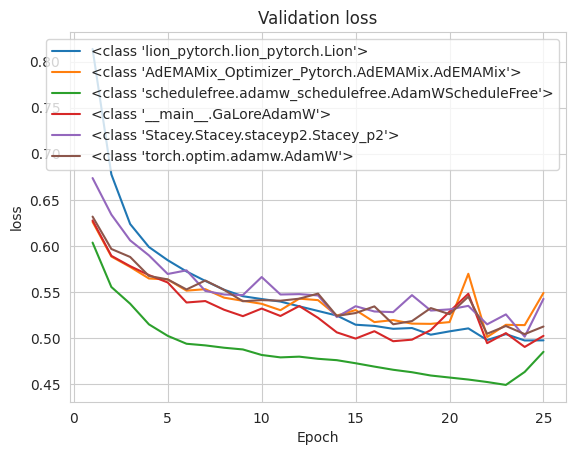


Plot saved to best_run_plots/best_run_accuracy.png


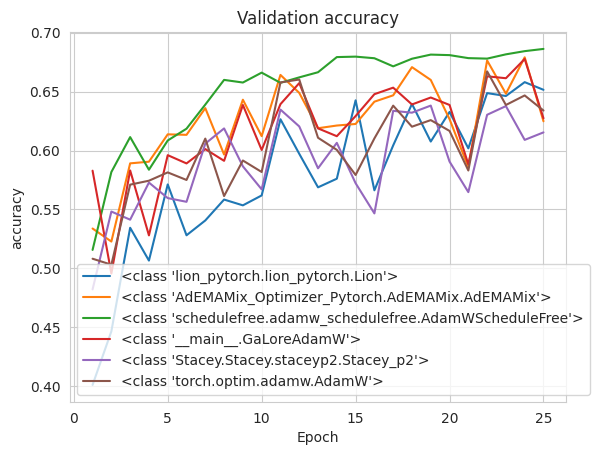


Plot saved to best_run_plots/best_run_f1score.png


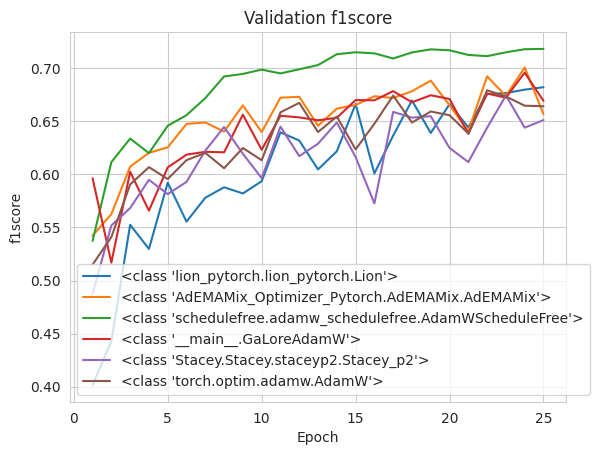


Plot saved to best_run_plots/best_run_precision.png


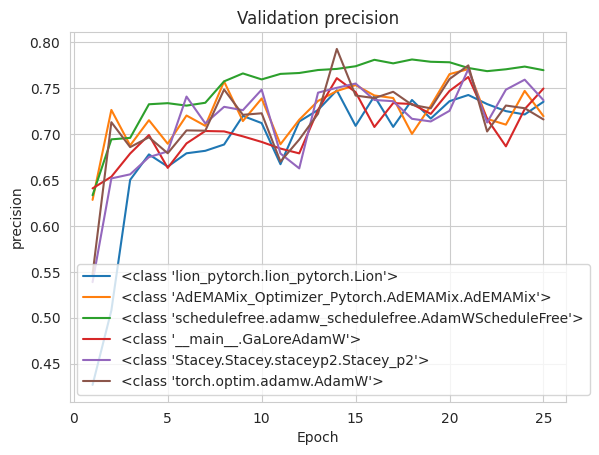


Plot saved to best_run_plots/best_run_recall.png


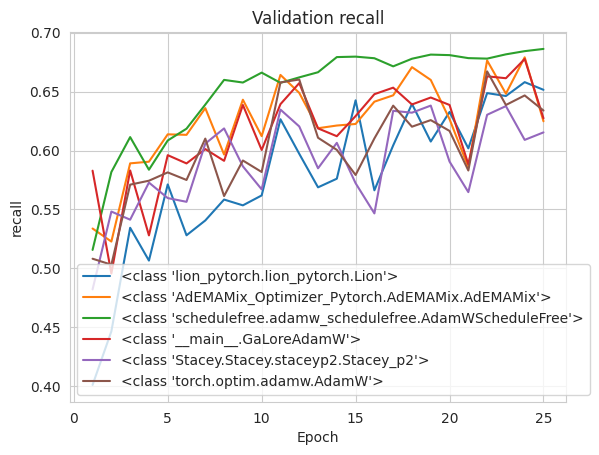

In [16]:
sns.set_style("whitegrid")

for metric in val_metric_dfs[next(iter(val_metric_dfs))]:
    for opt_cls in val_metric_dfs:
        plt.plot(val_metric_dfs[opt_cls][metric]['step'][:-1], val_metric_dfs[opt_cls][metric]['value'][:-1], label=opt_cls)
    plt.title(f'Validation {metric}')
    plt.xlabel('Epoch')
    plt.ylabel(metric)
    plt.legend()
    output_filename = f"best_run_plots/best_run_{metric}.png"
    plt.savefig(output_filename, dpi=300)
    print(f"\nPlot saved to {output_filename}")
    plt.show()

In [17]:
optimizer_comparison_acc_df = pd.DataFrame({"Optimizer": [repr(i)[repr(i).rfind('.') + 1: -2] for i in cls_analysis_optimizer], 
                                            "Config": [i.get_best_config(metric=f"val_accuracy", mode="max") for i in cls_analysis_optimizer.values()], 
                                            "Accuracy": [i.get_best_trial(metric=f"val_accuracy", mode="max").last_result[f"val_accuracy"] for i in cls_analysis_optimizer.values() ], 
                                            "F1Score": [i.get_best_trial(metric=f"val_accuracy", mode="max").last_result[f"val_f1score"] for i in cls_analysis_optimizer.values()], 
                                            "Precision": [i.get_best_trial(metric=f"val_accuracy", mode="max").last_result[f"val_precision"] for i in cls_analysis_optimizer.values()], 
                                            "Recall": [i.get_best_trial(metric=f"val_accuracy", mode="max").last_result[f"val_recall"] for i in cls_analysis_optimizer.values()], 
                                            "Time_total_s": [round(i.get_best_trial(metric=f"val_accuracy", mode="max").last_result['time_total_s'], 2) for i in cls_analysis_optimizer.values()],
                                           })

optimizer_comparison_acc_df

,Optimizer,Config,Accuracy,F1Score,Precision,Recall,Time_total_s
0,Lion,"{'lr': 0.001, 'weight_decay': 0, 'decoupled_weight_decay': False, 'use_triton': False, 'experiment_name': 'classification', 'tracking_uri': './mlruns'}",0.664726,0.689058,0.732636,0.664726,55.48
1,AdEMAMix,"{'lr': 0.01, 'weight_decay': 0, 'alpha': 10.0, 'experiment_name': 'classification', 'tracking_uri': './mlruns'}",0.639539,0.682344,0.750114,0.639539,47.95
2,AdamWScheduleFree,"{'lr': 0.1, 'weight_decay': 0.01, 'r': 1.0, 'weight_lr_power': 1.0, 'experiment_name': 'classification', 'tracking_uri': './mlruns'}",0.686669,0.719268,0.774122,0.686669,45.35
3,GaLoreAdamW,"{'lr': 0.01, 'weight_decay': 1e-05, 'correct_bias': False, 'no_deprecation_warning': True, 'experiment_name': 'classification', 'tracking_uri': './mlruns'}",0.626076,0.669016,0.760249,0.626076,49.41
4,Stacey_p2,"{'lr_tau': 0.001, 'lr_eta': 0.1, 'lr_alpha': 0.1, 'weight_decay': 0.001, 'experiment_name': 'classification', 'tracking_uri': './mlruns'}",0.614659,0.651095,0.746132,0.614659,56.69
5,AdamW,"{'lr': 0.01, 'weight_decay': 0.001, 'amsgrad': False, 'experiment_name': 'classification', 'tracking_uri': './mlruns'}",0.597198,0.645445,0.762745,0.597198,40.35


In [18]:
results = {}
TEST_NUM_EPOCHS = 51
TEST_EPOCH_STEP = 1

train_dataloader = DataLoader(
    dataset=ray.get(train_dataset_ref),
    batch_size=BATCH_SIZE,
    pin_memory=True,
    num_workers=2,
    shuffle=True,
    worker_init_fn=seed_worker,
    generator=TORCH_GENERATOR,
)
valid_dataloader = DataLoader(
    dataset=ray.get(valid_dataset_ref),
    batch_size=BATCH_SIZE,
    num_workers=2,
    pin_memory=True,
    shuffle=False,
    worker_init_fn=seed_worker,
    generator=TORCH_GENERATOR,
)
test_dataloader = DataLoader(
    dataset=ray.get(test_dataset_ref),
    batch_size=BATCH_SIZE,
    num_workers=2,
    pin_memory=True,
    shuffle=False,
    worker_init_fn=seed_worker,
    generator=TORCH_GENERATOR,
)

experiment_name = "tuned_classification"
experiment_id = get_or_create_experiment(experiment_name)
mlflow.set_experiment(experiment_id=experiment_id)

for optimizer_type, config in zip(OPTIMIZERS_PARAMS.keys(), optimizer_comparison_acc_df["Config"]):
    with mlflow.start_run(run_name=experiment_name+f"_opt_{str(optimizer_type)[str(optimizer_type).rfind('.')+1:-2]}") as run:
        model = SimpleClassificationModel(input_shape=INPUT_SHAPE, 
                                      hidden_units=HIDDEN_UNITS, 
                                      output_shape=num_classes, 
                                      activation_function=nn.ReLU(),
                                     )
        loss_fn = nn.CrossEntropyLoss()
        wrapper = LightningWrapper(model=model, 
                                   optimizer_class=optimizer_type, 
                                   optimizer_hparams={i: j for i, j in config.items() if i not in ["experiment_name", "tracking_uri"]}, 
                                   loss_fn=loss_fn, )
        mlflow.pytorch.autolog()
        trainer = pl.Trainer(callbacks=[schedule_free_cb, ],
                            limit_train_batches=BATCH_SIZE, 
                            max_epochs=NUM_EPOCHS,
                            accelerator="auto",
                            devices="auto",
                            enable_progress_bar=False,
                            enable_checkpointing=False,
        )
        try:
            start = time.perf_counter()
            trainer.fit(model=wrapper, 
                        train_dataloaders=train_dataloader,
                        val_dataloaders=valid_dataloader)
            end = time.perf_counter()
            time_training = end - start
            # final_metrics = trainer.callback_metrics
            metrics_to_save = trainer.test(model=wrapper, dataloaders=test_dataloader)[0]
            # print(metrics_to_save)
            metrics_to_save = {
                "test_accuracy":metrics_to_save.get("test_accuracy", 0.),
                "test_f1score": metrics_to_save.get("test_f1score", 0.),
                "test_precision": metrics_to_save.get("test_precision", 0.),
                "test_recall": metrics_to_save.get("test_recall", 0.),
            }
            
            metrics_to_save['time_training'] = time_training
        except (AssertionError, RuntimeError) as e:
            # Catch "grad", "c_tmp" (Stacey), or general "nan" errors
            error_str = str(e).lower()
            if "grad" in error_str or "c_tmp" in error_str or "nan" in error_str:
                print(f"caught Optimizer Instability (NaNs) for config: {config}. Skipping trial.")
                metrics_to_save = {
                    "test_loss": float("inf"), 
                    "test_accuracy": 0.,
                    "test_f1score": 0.,
                    "test_precision": 0.,
                    "test_recall": 0.,
                }
                metrics_to_save['time_training'] = float("inf")
            else:
                raise e # If it's a different error, let it crash
        except Exception as e:
             # General safety net
            if "nan" in str(e).lower():
                print(f"Caught generic NaN error. Skipping trial.")
                metrics_to_save = {
                    "test_loss": float("inf"), 
                    "test_accuracy": 0.,
                    "test_f1score": 0.,
                    "test_precision": 0.,
                    "test_recall": 0.,
                }
                metrics_to_save['time_training'] = float("inf")
            raise e
        optimizer_name = str(optimizer_type)[str(optimizer_type).rfind('.')+1:-2]
        print(f"{optimizer_name} was trained for {time_training} seconds")
        results[optimizer_name] = metrics_to_save
        
        model.eval() 
    
        dummy_input = torch.randn(1, 3, 32, INPUT_SHAPE) 
    
        trial_name = session.get_trial_name()
    
        output_dir = "/kaggle/working/models/tuned"
        os.makedirs(output_dir, exist_ok=True)
        
        onnx_file_path = os.path.join(output_dir, f"{optimizer_name}.onnx")
        torch.onnx.export(
            model,
            dummy_input,
            onnx_file_path,
            export_params=True,
            opset_version=11,
            do_constant_folding=True,
            input_names=['input'],
            output_names=['output'],
            dynamic_axes={'input' : {0 : 'batch_size'},
                          'output' : {0 : 'batch_size'}}
        )

E0000 00:00:1766684837.062053      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766684837.068550      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type                      | Params | Mode 
--------------------------------------------------------------------
0 | model         | SimpleClassificationModel | 3.4 K  | train
1 | loss_fn

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.6359655261039734     │
│       test_f1score        │    0.6574560403823853     │
│         test_loss         │    0.4975365400314331     │
│      test_precision       │    0.7029770016670227     │
│        test_recall        │    0.6359655261039734     │
└───────────────────────────┴───────────────────────────┘

/usr/local/lib/python3.11/dist-packages/ray/train/_internal/session.py:657: UserWarning: `get_trial_name` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type                      | Params | Mode 
--------------------------------------------------------------------
0 | model         | SimpleClassificationModel | 3.4 K  | train
1 | loss_fn       | CrossEntropyLoss          | 0      | train
2 | train_metrics | MetricCollection          | 0      | train
3 | val_metr

Lion was trained for 54.479150841999854 seconds


`Trainer.fit` stopped: `max_epochs=26` reached.
2025/12/25 17:48:55 WARNING mlflow.utils.requirements_utils: Found torch version (2.6.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torch==2.6.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/12/25 17:49:05 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.21.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torchvision==0.21.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


...

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type                      | Params | Mode 
--------------------------------------------------------------------
0 | model         | SimpleClassificationModel | 3.4 K  | train
1 | loss_fn       | CrossEntropyLoss          | 0      | train
2 | train_metrics | MetricCollection          | 0      | train
3 | val_metrics   | MetricCollection          | 0      | train
4 | test_metrics  | MetricCollection          | 0      | train
--------------------------------------------------------------------
3.4 K     Trainable params
0         Non-tr

Stacey_p2 was trained for 57.70080965099987 seconds


`Trainer.fit` stopped: `max_epochs=26` reached.
2025/12/25 17:52:31 WARNING mlflow.utils.requirements_utils: Found torch version (2.6.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torch==2.6.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/12/25 17:52:41 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.21.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torchvision==0.21.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.6500866413116455     │
│       test_f1score        │    0.6357062458992004     │
│         test_loss         │    0.5158029794692993     │
│      test_precision       │     0.667911171913147     │
│        test_recall        │    0.6500866413116455     │
└───────────────────────────┴───────────────────────────┘

AdamW was trained for 50.6711176230001 seconds


In [19]:
def get_metric_history_df(run_id: str, metric_name: str) -> pd.DataFrame:
    """Fetches the full history of a metric for a given run and returns it as a DataFrame."""
    history = client.get_metric_history(run_id, metric_name)
    df = pd.DataFrame(
        [{'step': m.step, 'value': m.value, 'timestamp': m.timestamp} for m in history]
    )
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    return df

In [20]:
experiment_name = "tuned_classification"
tuned_val_metric_dfs = {}
for opt_cls in results:
    print(f"Running for {opt_cls=}")
    analysis = results[opt_cls]
    mlflow_run_id = mlflow.search_runs(experiment_ids=[experiment_id], filter_string=f"attributes.run_name = '{experiment_name + '_opt_' + opt_cls}'").sort_values(by='start_time', ascending=False).iloc[0]['run_id']
    tuned_val_metric_dfs[opt_cls] = {}
    tuned_val_metric_dfs[opt_cls]['loss'] = get_metric_history_df(mlflow_run_id, "val_loss")
    tuned_val_metric_dfs[opt_cls]['accuracy'] = get_metric_history_df(mlflow_run_id, "val_accuracy")
    tuned_val_metric_dfs[opt_cls]['f1score'] = get_metric_history_df(mlflow_run_id, "val_f1score")
    tuned_val_metric_dfs[opt_cls]['precision'] = get_metric_history_df(mlflow_run_id, "val_precision")
    tuned_val_metric_dfs[opt_cls]['recall'] = get_metric_history_df(mlflow_run_id, "val_recall")
    print(f"Running for {opt_cls=}")
    print("\nValidation Loss History:")
    print(tuned_val_metric_dfs[opt_cls]['loss'].head())

Running for opt_cls='Lion'
Running for opt_cls='Lion'

Validation Loss History:
   step     value               timestamp
0     0  0.804698 2025-12-25 17:47:22.319
1     1  0.670902 2025-12-25 17:47:23.873
2     2  0.622948 2025-12-25 17:47:25.429
3     3  0.597801 2025-12-25 17:47:27.012
4     4  0.584192 2025-12-25 17:47:28.557
Running for opt_cls='AdEMAMix'
Running for opt_cls='AdEMAMix'

Validation Loss History:
   step     value               timestamp
0     0  0.621383 2025-12-25 17:48:15.830
1     1  0.607356 2025-12-25 17:48:17.430
2     2  0.585474 2025-12-25 17:48:19.099
3     3  0.555884 2025-12-25 17:48:20.676
4     4  0.568359 2025-12-25 17:48:22.298
Running for opt_cls='AdamWScheduleFree'
Running for opt_cls='AdamWScheduleFree'

Validation Loss History:
   step     value               timestamp
0     0  0.595684 2025-12-25 17:49:08.000
1     1  0.573607 2025-12-25 17:49:09.558
2     2  0.540113 2025-12-25 17:49:11.086
3     3  0.521250 2025-12-25 17:49:12.632
4     4  0.5


Plot saved to tuned_run_plots/best_tuned_run_loss.png


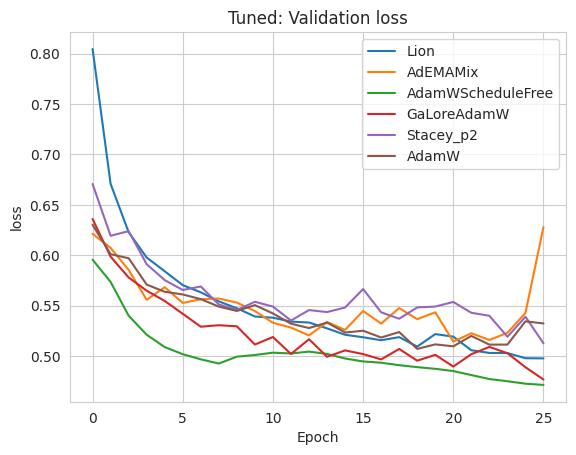


Plot saved to tuned_run_plots/best_tuned_run_accuracy.png


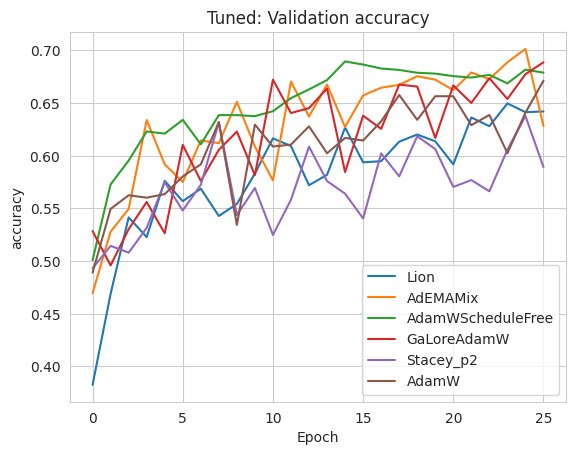


Plot saved to tuned_run_plots/best_tuned_run_f1score.png


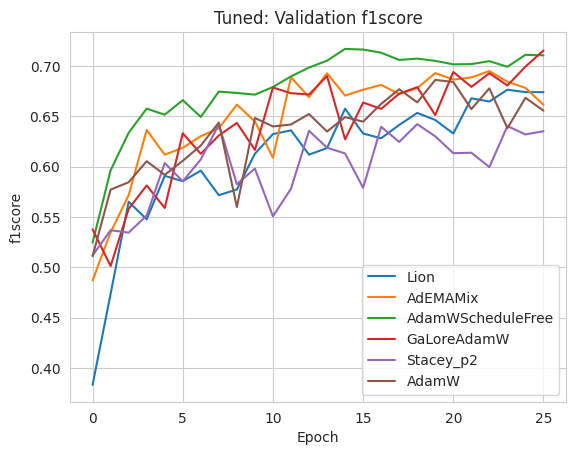


Plot saved to tuned_run_plots/best_tuned_run_precision.png


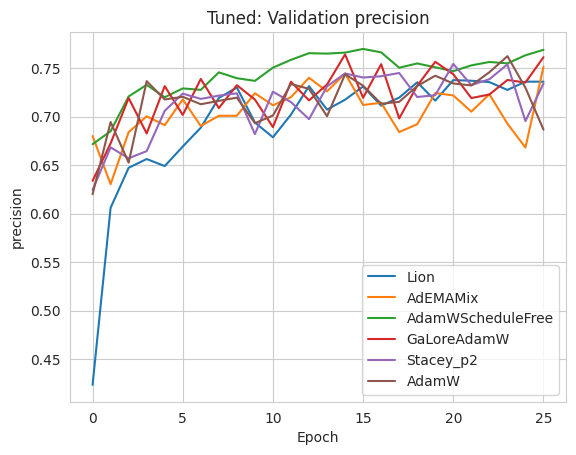


Plot saved to tuned_run_plots/best_tuned_run_recall.png


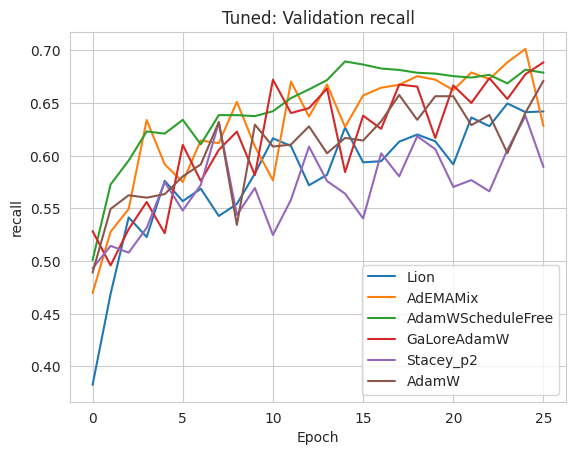

In [21]:
for metric in tuned_val_metric_dfs[next(iter(tuned_val_metric_dfs))]:
    for opt_cls in tuned_val_metric_dfs:
        plt.plot(tuned_val_metric_dfs[opt_cls][metric]['step'][:-1], tuned_val_metric_dfs[opt_cls][metric]['value'][:-1], label=opt_cls)
    plt.title(f'Tuned: Validation {metric}')
    plt.xlabel('Epoch')
    plt.ylabel(metric)
    plt.legend()
    output_filename = f"tuned_run_plots/best_tuned_run_{metric}.png"
    plt.savefig(output_filename, dpi=300)
    print(f"\nPlot saved to {output_filename}")
    plt.show()

In [22]:
default_results = {}

experiment_name = "default_classification"
experiment_id = get_or_create_experiment("default_classification")
mlflow.set_experiment(experiment_id=experiment_id)

for optimizer_type in OPTIMIZERS_PARAMS.keys():
    with mlflow.start_run(run_name=experiment_name+f"_opt_{str(optimizer_type)[str(optimizer_type).rfind('.')+1:-2]}") as run:
        model = SimpleClassificationModel(input_shape=INPUT_SHAPE, 
                                      hidden_units=HIDDEN_UNITS, 
                                      output_shape=num_classes, 
                                      activation_function=nn.ReLU(),
                                     )
        loss_fn = nn.CrossEntropyLoss()
        wrapper = LightningWrapper(model=model, 
                                   optimizer_class=optimizer_type, 
                                   optimizer_hparams={}, 
                                   loss_fn=loss_fn, )
        mlflow.pytorch.autolog()
        trainer = pl.Trainer(callbacks=[schedule_free_cb],
                            limit_train_batches=BATCH_SIZE, 
                            max_epochs=NUM_EPOCHS,
                            accelerator="auto",
                            devices="auto",
                            enable_progress_bar=False,
                            #strategy="ddp_notebook",
                            enable_checkpointing=False,
                            #logger=False,
        )
        try:
            start = time.perf_counter()
            trainer.fit(model=wrapper, 
                        train_dataloaders=train_dataloader,
                        val_dataloaders=valid_dataloader)
            end = time.perf_counter()
            time_training = end - start
            # final_metrics = trainer.callback_metrics
            metrics_to_save = trainer.test(model=wrapper, dataloaders=test_dataloader)[0]
            # print(metrics_to_save)
            metrics_to_save = {
                "test_accuracy": metrics_to_save.get("test_accuracy", 0.),
                "test_f1score": metrics_to_save.get("test_f1score", 0.),
                "test_precision": metrics_to_save.get("test_precision", 0.),
                "test_recall": metrics_to_save.get("test_recall", 0.),
            }
            
            metrics_to_save['time_training'] = time_training
        except (AssertionError, RuntimeError) as e:
            # Catch "grad", "c_tmp" (Stacey), or general "nan" errors
            error_str = str(e).lower()
            if "grad" in error_str or "c_tmp" in error_str or "nan" in error_str:
                print(f"caught Optimizer Instability (NaNs) for config: {config}. Skipping trial.")
                metrics_to_save = {
                    "test_accuracy": metrics_to_save.get("test_accuracy", 0.),
                    "test_f1score": metrics_to_save.get("test_f1score", 0.),
                    "test_precision": metrics_to_save.get("test_precision", 0.),
                    "test_recall": metrics_to_save.get("test_recall", 0.),
                }
                metrics_to_save['time_training'] = float("inf")
            else:
                raise e # If it's a different error, let it crash
        except Exception as e:
             # General safety net
            if "nan" in str(e).lower():
                print(f"Caught generic NaN error. Skipping trial.")
                metrics_to_save = {
                    "test_accuracy": metrics_to_save.get("test_accuracy", 0.),
                    "test_f1score": metrics_to_save.get("test_f1score", 0.),
                    "test_precision": metrics_to_save.get("test_precision", 0.),
                    "test_recall": metrics_to_save.get("test_recall", 0.),
                }
                metrics_to_save['time_training'] = float("inf")
            raise e
        optimizer_name = 'default_' + str(optimizer_type)[str(optimizer_type).rfind('.')+1:-2]
        print(f"{optimizer_name} was trained for {time_training} seconds")
        default_results[optimizer_name] = metrics_to_save
        
        model.eval() 
    
        dummy_input = torch.randn(1, 3, 32, INPUT_SHAPE) 
    
        trial_name = session.get_trial_name()
    
        optimizer_name = str(optimizer_type).split('.')[-1].replace("'>", "")
    
        output_dir = "/kaggle/working/models/default"
        os.makedirs(output_dir, exist_ok=True)
        
        onnx_file_path = os.path.join(output_dir, f"{optimizer_name}.onnx")
        torch.onnx.export(
            model,
            dummy_input,
            onnx_file_path,
            export_params=True,
            opset_version=11, # A common opset version
            do_constant_folding=True,
            input_names=['input'],
            output_names=['output'],
            dynamic_axes={'input' : {0 : 'batch_size'},
                          'output' : {0 : 'batch_size'}}
        )
        print(f"Successfully exported ONNX model to: {onnx_file_path}")
        

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type                      | Params | Mode 
--------------------------------------------------------------------
0 | model         | SimpleClassificationModel | 3.4 K  | train
1 | loss_fn       | CrossEntropyLoss          | 0      | train
2 | train_metrics | MetricCollection          | 0      | train
3 | val_metrics   | MetricCollection          | 0      | train
4 | test_metrics  | MetricCollection          | 0      | train
--------------------------------------------------------------------
3.4 K     Trainable params
0         Non-tr

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.5203251838684082     │
│       test_f1score        │    0.5419721603393555     │
│         test_loss         │    0.5954795479774475     │
│      test_precision       │    0.6604899168014526     │
│        test_recall        │    0.5203251838684082     │
└───────────────────────────┴───────────────────────────┘

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type                      | Params | Mode 
--------------------------------------------------------------------
0 | model         | SimpleClassificationModel | 3.4 K  | train
1 | loss_fn       | CrossEntropyLoss          | 0      | train
2 | train_metrics | MetricCollection          | 0      | train
3 | val_metrics   | MetricCollection          | 0      | train
4 | test_metrics  | MetricCollection          | 0      | train
--------------------------------------------------------------------
3.4 K     Trainable params
0         Non-tr

default_Lion was trained for 51.45752741100023 seconds
Successfully exported ONNX model to: /kaggle/working/models/default/Lion.onnx


`Trainer.fit` stopped: `max_epochs=26` reached.
2025/12/25 17:54:18 WARNING mlflow.utils.requirements_utils: Found torch version (2.6.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torch==2.6.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/12/25 17:54:28 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.21.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torchvision==0.21.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


...

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type                      | Params | Mode 
--------------------------------------------------------------------
0 | model         | SimpleClassificationModel | 3.4 K  | train
1 | loss_fn       | CrossEntropyLoss          | 0      | train
2 | train_metrics | MetricCollection          | 0      | train
3 | val_metrics   | MetricCollection          | 0      | train
4 | test_metrics  | MetricCollection          | 0      | train
--------------------------------------------------------------------
3.4 K     Trainable params
0         Non-tr

default_Stacey_p2 was trained for 58.082535624999764 seconds
Successfully exported ONNX model to: /kaggle/working/models/default/Stacey_p2.onnx


`Trainer.fit` stopped: `max_epochs=26` reached.
2025/12/25 17:57:54 WARNING mlflow.utils.requirements_utils: Found torch version (2.6.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torch==2.6.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/12/25 17:58:04 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.21.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torchvision==0.21.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.5709186792373657     │
│       test_f1score        │    0.5932108163833618     │
│         test_loss         │    0.5409570932388306     │
│      test_precision       │     0.683021068572998     │
│        test_recall        │    0.5709186792373657     │
└───────────────────────────┴───────────────────────────┘

default_AdamW was trained for 50.77420296599985 seconds
Successfully exported ONNX model to: /kaggle/working/models/default/AdamW.onnx


In [23]:
default_val_metric_dfs = {}
experiment_name = "default_classification"
experiment_id = get_or_create_experiment("default_classification")
for opt_cls in default_results:
    analysis = default_results[opt_cls]
    mlflow_run_id = mlflow.search_runs(experiment_ids=[experiment_id], filter_string=f"attributes.run_name = '{experiment_name}_opt_{opt_cls[opt_cls.find('_') + 1:]}'").sort_values(by='start_time', ascending=False).iloc[0]['run_id']
    default_val_metric_dfs[opt_cls] = {}
    default_val_metric_dfs[opt_cls]['loss'] = get_metric_history_df(mlflow_run_id, "val_loss")
    default_val_metric_dfs[opt_cls]['accuracy'] = get_metric_history_df(mlflow_run_id, "val_accuracy")
    default_val_metric_dfs[opt_cls]['f1score'] = get_metric_history_df(mlflow_run_id, "val_f1score")
    default_val_metric_dfs[opt_cls]['precision'] = get_metric_history_df(mlflow_run_id, "val_precision")
    default_val_metric_dfs[opt_cls]['recall'] = get_metric_history_df(mlflow_run_id, "val_recall")
    print(f"Running for {opt_cls=}")
    print("\nValidation Loss History:")
    print(default_val_metric_dfs[opt_cls]['loss'].head())

Running for opt_cls='default_Lion'

Validation Loss History:
   step     value               timestamp
0     0  1.718266 2025-12-25 17:52:46.298
1     1  1.458648 2025-12-25 17:52:47.904
2     2  1.223661 2025-12-25 17:52:49.458
3     3  1.029558 2025-12-25 17:52:51.063
4     4  0.897285 2025-12-25 17:52:52.692
Running for opt_cls='default_AdEMAMix'

Validation Loss History:
   step     value               timestamp
0     0  0.779558 2025-12-25 17:53:38.184
1     1  0.696455 2025-12-25 17:53:39.796
2     2  0.660148 2025-12-25 17:53:41.371
3     3  0.638844 2025-12-25 17:53:43.087
4     4  0.625389 2025-12-25 17:53:44.791
Running for opt_cls='default_AdamWScheduleFree'

Validation Loss History:
   step     value               timestamp
0     0  0.753983 2025-12-25 17:54:30.592
1     1  0.682197 2025-12-25 17:54:32.179
2     2  0.654140 2025-12-25 17:54:33.684
3     3  0.636993 2025-12-25 17:54:35.225
4     4  0.623743 2025-12-25 17:54:36.761
Running for opt_cls='default_GaLoreAdamW'

V


Plot saved to default_run_plots/best_default_run_loss.png


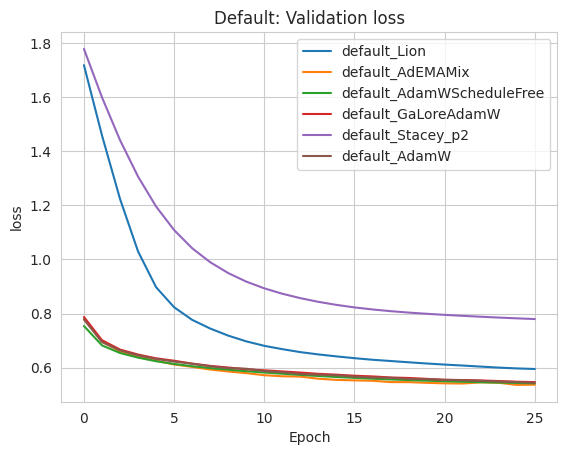


Plot saved to default_run_plots/best_default_run_accuracy.png


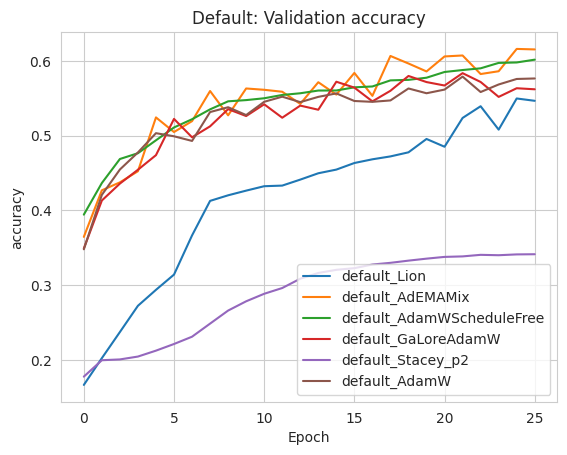


Plot saved to default_run_plots/best_default_run_f1score.png


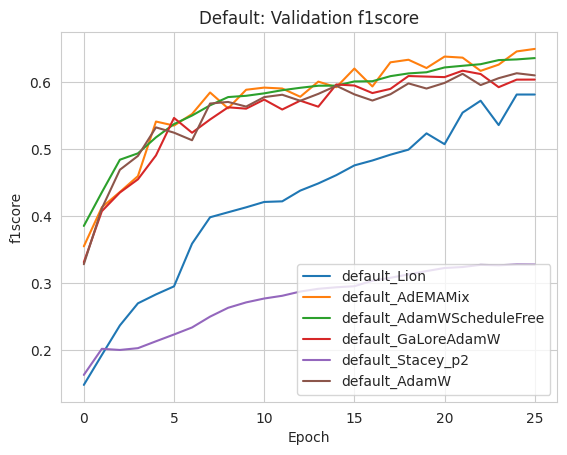


Plot saved to default_run_plots/best_default_run_precision.png


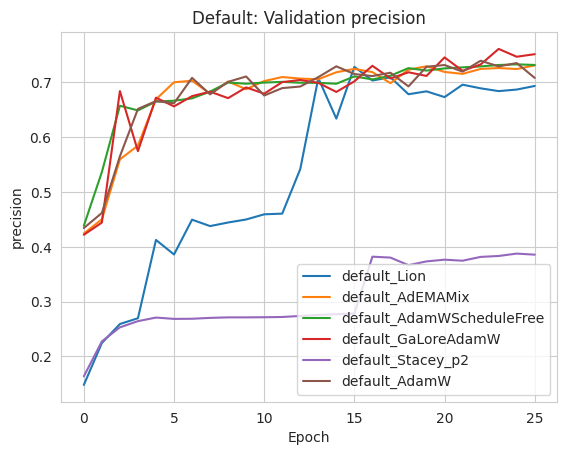


Plot saved to default_run_plots/best_default_run_recall.png


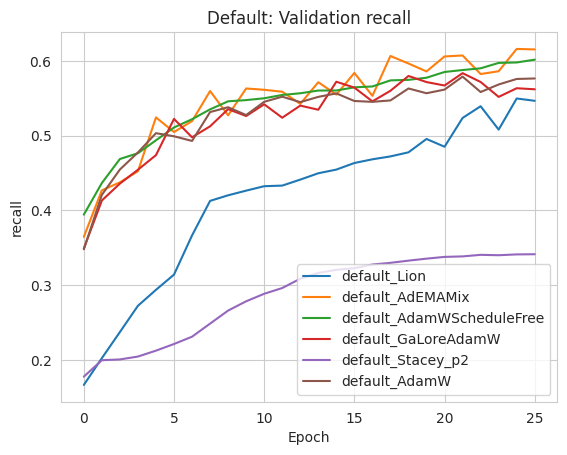

In [24]:
for metric in default_val_metric_dfs[next(iter(default_val_metric_dfs))]:
    for opt_cls in default_val_metric_dfs:
        plt.plot(default_val_metric_dfs[opt_cls][metric]['step'][:-1], default_val_metric_dfs[opt_cls][metric]['value'][:-1], label=opt_cls)
    plt.title(f'Default: Validation {metric}')
    plt.xlabel('Epoch')
    plt.ylabel(metric)
    plt.legend()
    output_filename = f"default_run_plots/best_default_run_{metric}.png"
    plt.savefig(output_filename, dpi=300)
    print(f"\nPlot saved to {output_filename}")
    plt.show()


In [25]:
results_df = pd.DataFrame(results).T
results_df = pd.concat([results_df, pd.DataFrame(optimizer_comparison_acc_df['Config']).set_index(results_df.index)], axis=1)
results_df

,test_accuracy,test_f1score,test_precision,test_recall,time_training,Config
Lion,0.635966,0.657456,0.702977,0.635966,54.479151,"{'lr': 0.001, 'weight_decay': 0, 'decoupled_weight_decay': False, 'use_triton': False, 'experiment_name': 'classification', 'tracking_uri': './mlruns'}"
AdEMAMix,0.629862,0.654400,0.756121,0.629862,51.785757,"{'lr': 0.01, 'weight_decay': 0, 'alpha': 10.0, 'experiment_name': 'classification', 'tracking_uri': './mlruns'}"
AdamWScheduleFree,0.683893,0.702768,0.755965,0.683893,50.347891,"{'lr': 0.1, 'weight_decay': 0.01, 'r': 1.0, 'weight_lr_power': 1.0, 'experiment_name': 'classification', 'tracking_uri': './mlruns'}"
GaLoreAdamW,0.665172,0.688592,0.748195,0.665172,54.861752,"{'lr': 0.01, 'weight_decay': 1e-05, 'correct_bias': False, 'no_deprecation_warning': True, 'experiment_name': 'classification', 'tracking_uri': './mlruns'}"
Stacey_p2,0.587476,0.626127,0.721166,0.587476,57.700810,"{'lr_tau': 0.001, 'lr_eta': 0.1, 'lr_alpha': 0.1, 'weight_decay': 0.001, 'experiment_name': 'classification', 'tracking_uri': './mlruns'}"
AdamW,0.650087,0.635706,0.667911,0.650087,50.671118,"{'lr': 0.01, 'weight_decay': 0.001, 'amsgrad': False, 'experiment_name': 'classification', 'tracking_uri': './mlruns'}"


In [26]:
results_df = pd.DataFrame(results).T
results_df = pd.concat([results_df, pd.DataFrame(optimizer_comparison_acc_df['Config']).set_index(results_df.index)], axis=1)

default_results_df = pd.DataFrame(default_results).T
default_results_df['Config'] = [{i: j for i, j in zip(inspect.getfullargspec(optimizer.__init__).args[2:], inspect.getfullargspec(optimizer.__init__).defaults)} for optimizer in OPTIMIZERS_PARAMS]

pd.concat([results_df, default_results_df])

,test_accuracy,test_f1score,test_precision,test_recall,time_training,Config
Lion,0.635966,0.657456,0.702977,0.635966,54.479151,"{'lr': 0.001, 'weight_decay': 0, 'decoupled_weight_decay': False, 'use_triton': False, 'experiment_name': 'classification', 'tracking_uri': './mlruns'}"
AdEMAMix,0.629862,0.654400,0.756121,0.629862,51.785757,"{'lr': 0.01, 'weight_decay': 0, 'alpha': 10.0, 'experiment_name': 'classification', 'tracking_uri': './mlruns'}"
AdamWScheduleFree,0.683893,0.702768,0.755965,0.683893,50.347891,"{'lr': 0.1, 'weight_decay': 0.01, 'r': 1.0, 'weight_lr_power': 1.0, 'experiment_name': 'classification', 'tracking_uri': './mlruns'}"
GaLoreAdamW,0.665172,0.688592,0.748195,0.665172,54.861752,"{'lr': 0.01, 'weight_decay': 1e-05, 'correct_bias': False, 'no_deprecation_warning': True, 'experiment_name': 'classification', 'tracking_uri': './mlruns'}"
Stacey_p2,0.587476,0.626127,0.721166,0.587476,57.700810,"{'lr_tau': 0.001, 'lr_eta': 0.1, 'lr_alpha': 0.1, 'weight_decay': 0.001, 'experiment_name': 'classification', 'tracking_uri': './mlruns'}"
AdamW,0.650087,0.635706,0.667911,0.650087,50.671118,"{'lr': 0.01, 'weight_decay': 0.001, 'amsgrad': False, 'experiment_name': 'classification', 'tracking_uri': './mlruns'}"
default_Lion,0.520325,0.541972,0.660490,0.520325,51.457527,"{'lr': 0.0001, 'betas': (0.9, 0.99), 'weight_decay': 0.0, 'use_triton': False, 'decoupled_weight_decay': False}"
default_AdEMAMix,0.589812,0.610366,0.699953,0.589812,52.079205,"{'lr': 0.001, 'betas': (0.9, 0.999, 0.9999), 'eps': 1e-08, 'weight_decay': 0, 'alpha': 5.0, 'T_alpha_beta3': None}"
default_AdamWScheduleFree,0.576624,0.599919,0.683529,0.576624,50.443030,"{'lr': 0.0025, 'betas': (0.9, 0.999), 'eps': 1e-08, 'weight_decay': 0, 'warmup_steps': 0, 'r': 0.0, 'weight_lr_power': 2.0, 'foreach': True}"
default_GaLoreAdamW,0.550475,0.580009,0.710548,0.550475,55.122400,"{'lr': 0.001, 'betas': (0.9, 0.999), 'eps': 1e-06, 'weight_decay': 0.0, 'correct_bias': True, 'no_deprecation_warning': False}"


In [27]:
experiment_name = "tuned_classification_rs"
experiment_id = get_or_create_experiment(experiment_name)
mlflow.set_experiment(experiment_id=experiment_id)

rs_results = {}
random_seeds = np.random.randint(low=0, high=10**8, size=10)
for optimizer_type, config in zip(OPTIMIZERS_PARAMS.keys(), optimizer_comparison_acc_df["Config"]):
    rs_results[optimizer_type] = []
    for rs in random_seeds:
        seed_everything(rs)
        opt_name = str(optimizer_type)[str(optimizer_type).rfind('.')+1:-2]
        with mlflow.start_run(run_name=experiment_name+f"_opt_{opt_name}_rs_{rs}") as run:
            params_to_log = {i: j for i, j in config.items()}
            mlflow.log_params(params_to_log)
            
            mlflow.set_tag("optimizer", opt_name)
            mlflow.set_tag("random_seed", rs)
            model = SimpleClassificationModel(input_shape=INPUT_SHAPE, 
                                      hidden_units=HIDDEN_UNITS, 
                                      output_shape=num_classes, 
                                      activation_function=nn.ReLU(),
                                     )
            loss_fn = nn.CrossEntropyLoss()
            wrapper = LightningWrapper(model=model, 
                                       optimizer_class=optimizer_type, 
                                       optimizer_hparams={i: j for i, j in config.items() if i not in ["experiment_name", "tracking_uri"]}, 
                                       loss_fn=loss_fn, )
            # mlflow.pytorch.autolog()
            trainer = pl.Trainer(callbacks=[schedule_free_cb, ],
                                limit_train_batches=BATCH_SIZE, 
                                max_epochs=NUM_EPOCHS,
                                accelerator="auto",
                                devices="auto",
                                enable_progress_bar=False,
                                #strategy="ddp_notebook",
                                enable_checkpointing=False,
                                #logger=False,
            )
            start = time.perf_counter()
            trainer.fit(model=wrapper, 
                        train_dataloaders=train_dataloader,
                        val_dataloaders=valid_dataloader,)
            end = time.perf_counter()
            time_training = end - start
            # final_metrics = trainer.callback_metrics
            metrics_to_save = trainer.test(model=wrapper, dataloaders=test_dataloader)[0]
            # print(metrics_to_save)
            metrics_to_save = {
                "test_accuracy": metrics_to_save.get("test_accuracy", 0.),
                "test_f1score": metrics_to_save.get("test_f1score", 0.),
                "test_precision": metrics_to_save.get("test_precision", 0.),
                "test_recall": metrics_to_save.get("test_recall", 0.),
            }
            
            metrics_to_save['time_training'] = time_training
            metrics_to_save['random_state'] = rs
            optimizer_name = str(optimizer_type)[str(optimizer_type).rfind('.')+1:-2]
            print(f"{optimizer_name} with random state {rs} was trained for {time_training} seconds")
            rs_results[optimizer_type].append(metrics_to_save)

            model.eval() 
    
            dummy_input = torch.randn(1, 3, 32, INPUT_SHAPE) 
        
            trial_name = session.get_trial_name()
        
            optimizer_name = str(optimizer_type).split('.')[-1].replace("'>", "")
        
            output_dir = "/kaggle/working/models/varying_random_state"
            os.makedirs(output_dir, exist_ok=True)
            
            onnx_file_path = os.path.join(output_dir, f"{optimizer_name}_{rs}.onnx")
            torch.onnx.export(
                model,
                dummy_input,
                onnx_file_path,
                export_params=True,
                opset_version=11,
                do_constant_folding=True,
                input_names=['input'],
                output_names=['output'],
                dynamic_axes={'input' : {0 : 'batch_size'},
                              'output' : {0 : 'batch_size'}}
            )
            print(f"Successfully exported ONNX model to: {onnx_file_path}")
            

Seed set to 37914296
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type                      | Params | Mode 
--------------------------------------------------------------------
0 | model         | SimpleClassificationModel | 3.4 K  | train
1 | loss_fn       | CrossEntropyLoss          | 0      | train
2 | train_metrics | MetricCollection          | 0      | train
3 | val_metrics   | MetricCollection          | 0      | train
4 | test_metrics  | MetricCollection          | 0      | train
--------------------------------------------------------------------
3.4 K     Trainable pa

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.6396969556808472     │
│       test_f1score        │    0.6600813865661621     │
│         test_loss         │    0.49819326400756836    │
│      test_precision       │    0.7232863903045654     │
│        test_recall        │    0.6396969556808472     │
└───────────────────────────┴───────────────────────────┘

Seed set to 36344984
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type                      | Params | Mode 
--------------------------------------------------------------------
0 | model         | SimpleClassificationModel | 3.4 K  | train
1 | loss_fn       | CrossEntropyLoss          | 0      | train
2 | train_metrics | MetricCollection          | 0      | train
3 | val_metrics   | MetricCollection          | 0      | train
4 | test_metrics  | MetricCollection          | 0      | train
--------------------------------------------------------------------
3.4 K     Trainable pa

Lion with random state 37914296 was trained for 51.326074036000136 seconds
Successfully exported ONNX model to: /kaggle/working/models/varying_random_state/Lion_37914296.onnx


`Trainer.fit` stopped: `max_epochs=26` reached.
2025/12/25 17:59:41 WARNING mlflow.utils.requirements_utils: Found torch version (2.6.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torch==2.6.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/12/25 17:59:50 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.21.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torchvision==0.21.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


...

Seed set to 88331393
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type                      | Params | Mode 
--------------------------------------------------------------------
0 | model         | SimpleClassificationModel | 3.4 K  | train
1 | loss_fn       | CrossEntropyLoss          | 0      | train
2 | train_metrics | MetricCollection          | 0      | train
3 | val_metrics   | MetricCollection          | 0      | train
4 | test_metrics  | MetricCollection          | 0      | train
--------------------------------------------------------------------
3.4 K     Trainable pa

AdamW with random state 44223837 was trained for 51.88300240699937 seconds
Successfully exported ONNX model to: /kaggle/working/models/varying_random_state/AdamW_44223837.onnx


`Trainer.fit` stopped: `max_epochs=26` reached.
2025/12/25 18:51:34 WARNING mlflow.utils.requirements_utils: Found torch version (2.6.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torch==2.6.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/12/25 18:51:44 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.21.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torchvision==0.21.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │     0.624759316444397     │
│       test_f1score        │    0.6441501379013062     │
│         test_loss         │    0.5215350985527039     │
│      test_precision       │    0.7074021697044373     │
│        test_recall        │     0.624759316444397     │
└───────────────────────────┴───────────────────────────┘

AdamW with random state 88331393 was trained for 51.787889674000326 seconds
Successfully exported ONNX model to: /kaggle/working/models/varying_random_state/AdamW_88331393.onnx


In [28]:
rs_dfs = pd.DataFrame([
    result_dict | {'optimizer': str(optimizer_key)[str(optimizer_key).rfind('.') + 1: -2]}
    for optimizer_key in rs_results
    for result_dict in rs_results[optimizer_key]
])
rs_dfs

,test_accuracy,test_f1score,test_precision,test_recall,time_training,random_state,optimizer
0,0.639697,0.660081,0.723286,0.639697,51.326074,37914296,Lion
1,0.625090,0.647142,0.704415,0.625090,51.224987,36344984,Lion
2,0.655151,0.656017,0.676967,0.655151,51.292908,96717074,Lion
3,0.651554,0.663797,0.705797,0.651554,51.633363,14827048,Lion
4,0.626468,0.649421,0.713158,0.626468,51.103164,44985782,Lion
5,0.638792,0.653323,0.716874,0.638792,51.362916,39141583,Lion
6,0.652791,0.678083,0.731757,0.652791,51.197289,73153291,Lion
7,0.633984,0.658011,0.726288,0.633984,51.256175,32061551,Lion
8,0.644225,0.660940,0.729246,0.644225,51.187908,44223837,Lion
9,0.624351,0.651946,0.739171,0.624351,51.269164,88331393,Lion



Plot saved to varying_rs_run_plots/best_run_rs_test_accuracy.png


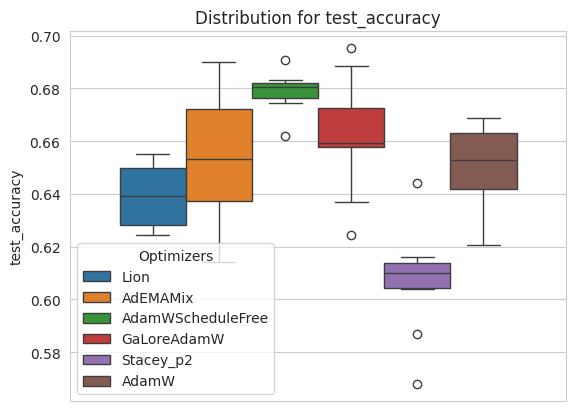


Plot saved to varying_rs_run_plots/best_run_rs_test_f1score.png


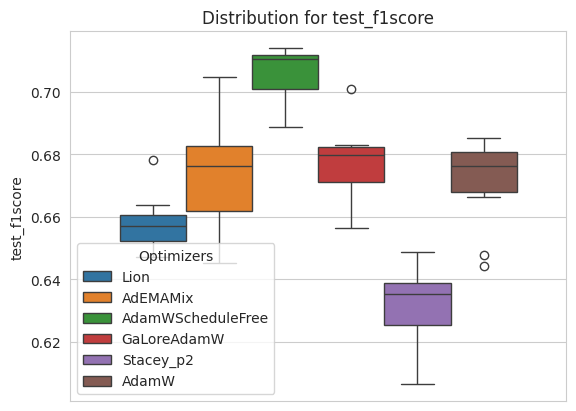


Plot saved to varying_rs_run_plots/best_run_rs_test_precision.png


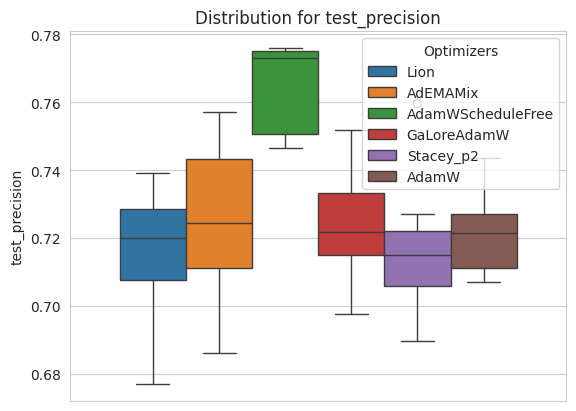


Plot saved to varying_rs_run_plots/best_run_rs_test_recall.png


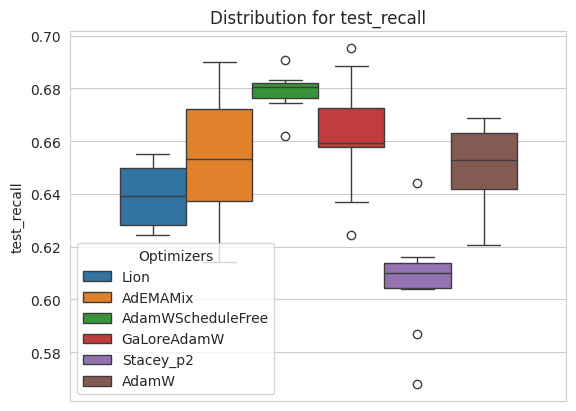

In [29]:
test_metrics = ['test_accuracy', 'test_f1score', 'test_precision', 'test_recall']
for m in test_metrics:
    sns.boxplot(data=rs_dfs, hue='optimizer', y=m)
    plt.legend(title="Optimizers")
    plt.title(f"Distribution for {m}")
    output_filename = f"varying_rs_run_plots/best_run_rs_{m}.png"
    plt.savefig(output_filename, dpi=300)
    print(f"\nPlot saved to {output_filename}")
    plt.show()